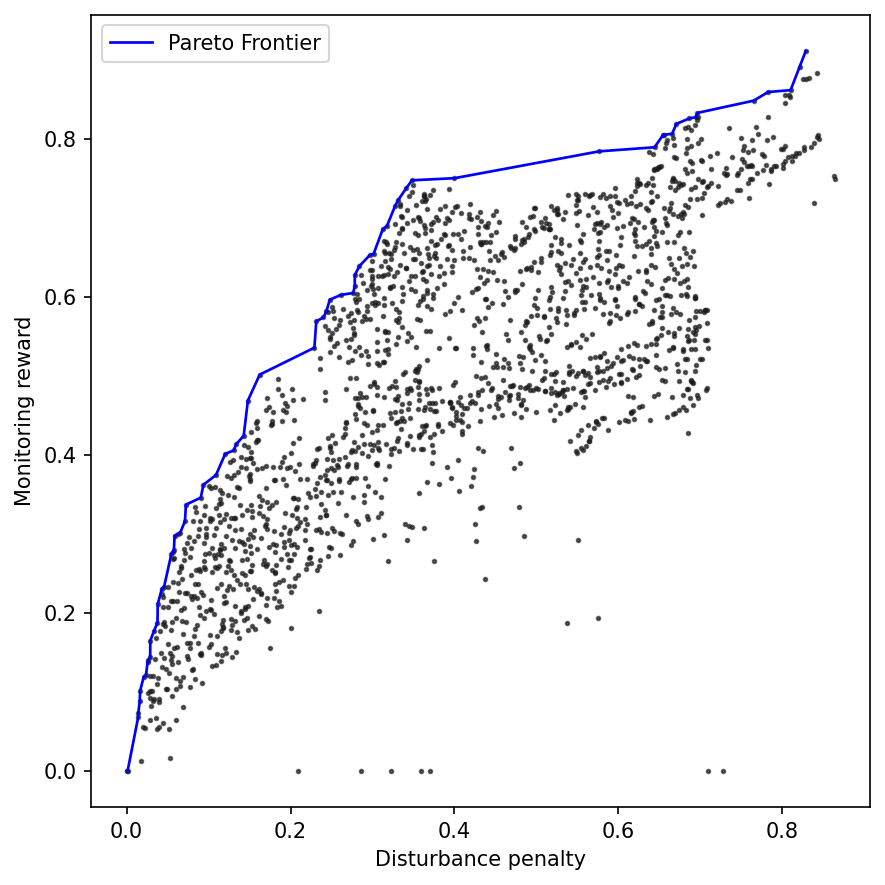

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("table/all_model_episode_rewards.csv")

xcol = "p_disturbance"
ycol = "r_monitoring"

x = df[xcol].to_numpy()
y = df[ycol].to_numpy()

# Optional density thinning
xbins = np.linspace(x.min(), x.max(), 50)
ybins = np.linspace(y.min(), y.max(), 50)

ix = np.clip(np.digitize(x, xbins) - 1, 0, len(xbins) - 2)
iy = np.clip(np.digitize(y, ybins) - 1, 0, len(ybins) - 2)

cell_ids = list(zip(ix, iy))
cell_counts = pd.Series(cell_ids).value_counts()
counts = np.array([cell_counts[c] for c in cell_ids])

rng = np.random.default_rng(42)
keep_prob = np.minimum(1.0, 4 / counts)
keep_mask = rng.random(len(df)) < keep_prob

df_sparse = df.loc[keep_mask].copy()
df_sparse = df_sparse.drop_duplicates(subset=[xcol, ycol])

# Save thinned version separately so you don't overwrite original by mistake
df_sparse.to_csv("table/all_model_episode_rewards_sparse.csv", index=False)

# Pareto frontier: minimize x, maximize y
pts = df_sparse[[xcol, ycol]].dropna().to_numpy()

# Sort by x ascending, then y descending
pts = pts[np.lexsort((-pts[:, 1], pts[:, 0]))]

pareto = []
best_y = -np.inf

for px, py in pts:
    if py > best_y:
        pareto.append((px, py))
        best_y = py

pareto = np.array(pareto)

fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

ax.scatter(
    df_sparse[xcol],
    df_sparse[ycol],
    s=11,
    alpha=0.66,
    color="#1C1C1C",
    marker="."
)

ax.plot(
    pareto[:, 0],
    pareto[:, 1],
    color="blue",
    linewidth=1.3,
    label="Pareto Frontier"
)

ax.set_xlabel("Disturbance penalty")
ax.set_ylabel("Monitoring reward")
ax.legend()
plt.tight_layout()
plt.show()

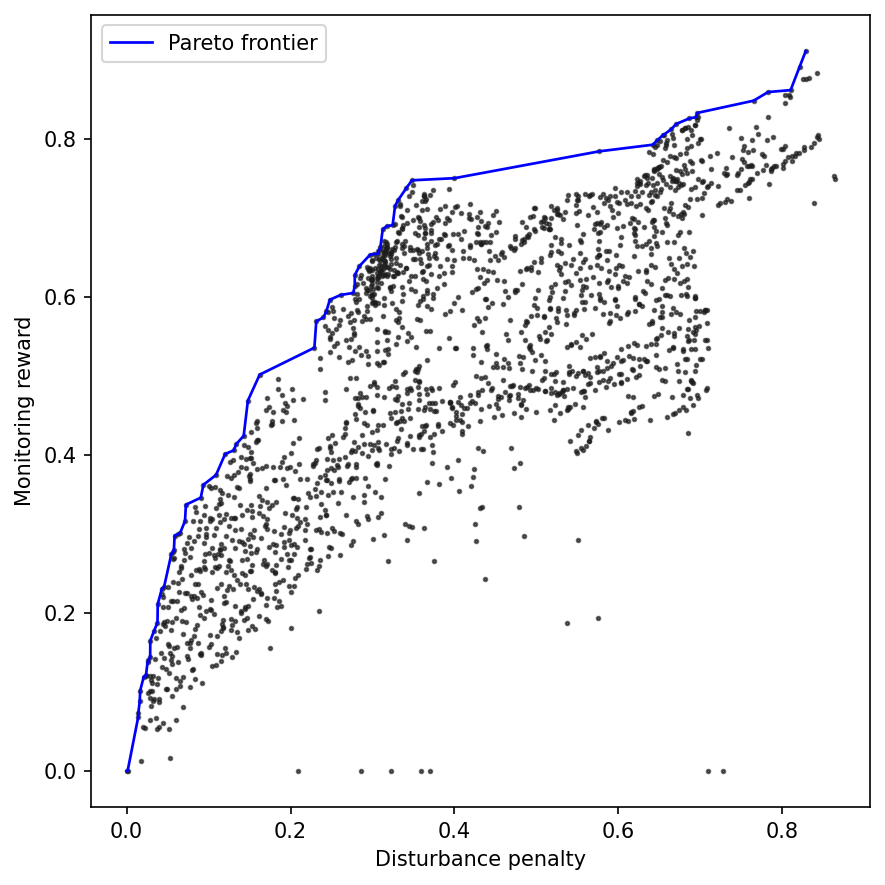

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

xcol = "p_disturbance"
ycol = "r_monitoring"

base_file = Path("table/all_model_episode_rewards.csv")
sparse_file = Path("table/all_model_episode_rewards_sparse.csv")

# load new results
df_new = pd.read_csv(base_file)

# load existing accumulated results if present
if sparse_file.exists():
    df_existing = pd.read_csv(sparse_file)
    df_all = pd.concat([df_existing, df_new], ignore_index=True)
else:
    df_all = df_new.copy()

# remove duplicates
df_all = df_all.drop_duplicates(subset=[xcol, ycol])

# save updated accumulated dataset
df_all.to_csv(sparse_file, index=False)

# ----- compute Pareto frontier -----
pts = df_all[[xcol, ycol]].dropna().to_numpy()

# sort by disturbance ascending, monitoring descending
pts = pts[np.lexsort((-pts[:, 1], pts[:, 0]))]

pareto = []
best_y = -np.inf

for px, py in pts:
    if py > best_y:
        pareto.append((px, py))
        best_y = py

pareto = np.array(pareto)

# ----- plot -----
fig, ax = plt.subplots(figsize=(6, 6), dpi=150)

ax.scatter(
    df_all[xcol],
    df_all[ycol],
    s=11,
    alpha=0.65,
    color="#1C1C1C",
    marker="."
)

ax.plot(
    pareto[:, 0],
    pareto[:, 1],
    color="blue",
    linewidth=1.3,
    label="Pareto frontier"
)

ax.set_xlabel("Disturbance penalty")
ax.set_ylabel("Monitoring reward")

ax.legend()
plt.tight_layout()
plt.show()